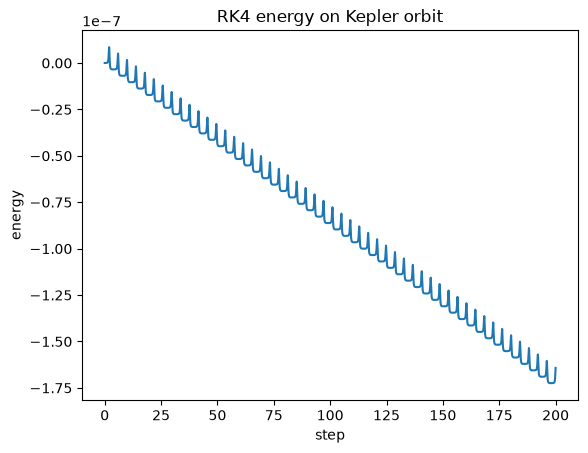

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

GM = 1.0

def accel(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    return np.array([vx, vy, -GM*x/r**3, -GM*y/r**3])

def rk4_step(s, h):
    k1 = accel(s)
    k2 = accel(s + 0.5*h*k1)
    k3 = accel(s + 0.5*h*k2)
    k4 = accel(s + h*k3)
    return s + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def energy(s):
    x, y, vx, vy = s
    r = np.sqrt(x**2 + y**2)
    return 0.5*(vx**2 + vy**2) - GM/r  

s = np.array([1.0, 0.0, 0.0, 0.8])
h = 0.01
N = 20000

E0 = energy(s)
drift = []
for i in range(N):
    s = rk4_step(s, h)
    drift.append((energy(s) - E0) / abs(E0)) 

plt.plot(np.arange(N) * h, drift)                             # <-- look here
plt.xlabel('time')
plt.ylabel('energy')
plt.title('RK4 energy on Kepler orbit')
plt.show()